In [1]:
import sys
sys.path.append('../code')

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import make_network, set_train_parameters, simulate, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse
from network_utils import get_prior_dict
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

import intrinsic_prior_configurations as prior_config

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [2]:
comp = jx.Compartment()
branch = jx.Branch(comp, ncomp=1)

E_cell = jx.Cell(branch, parents=[-1])
I_cell = jx.Cell(branch, parents=[-1])
context_cell = jx.Cell()
cue_cell = jx.Cell()
rate_cell = jx.Cell()
output_cell = jx.Cell()

num_E_cells = 100
num_I_cells = 50
num_context_cells = 50
num_cue_cells = 50

net_dict = {
    'E': {'num_cells': num_E_cells, 'cell': E_cell},
    'I': {'num_cells': num_I_cells, 'cell': I_cell},
    'context': {'num_cells': num_context_cells, 'cell': context_cell},
    'cue': {'num_cells': num_cue_cells, 'cell': cue_cell},
    'E_rate': {'num_cells': num_E_cells, 'cell': rate_cell},
    'I_rate': {'num_cells': num_I_cells, 'cell': rate_cell},
}

gid_ranges = dict()
cell_list = list()
cell_count = 0
for name, cell_dict in net_dict.items():
    num_cells = cell_dict['num_cells']
    gid_ranges[name] = range(cell_count, cell_count + num_cells)
    cell_list.extend([cell_dict['cell'] for _ in range(num_cells)])
    cell_count += num_cells




ERROR:2025-05-29 13:05:55,273:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 135, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 230, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/users/ntolley/.c

In [3]:
# net, gid_ranges = make_network()
# with open('jaxley_net.pkl', 'wb') as f:
#     pickle.dump((net, gid_ranges),f)

# with open('jaxley_net.pkl', 'rb') as f:
#     net, gid_ranges = pickle.load(f)

# num_E_cells, num_I_cells = len(gid_ranges['E']), len(gid_ranges['I'])
# num_cue_cells = len(gid_ranges['cue'])

# parameters, _ = set_train_parameters(net, gid_ranges)
prior_dict = get_prior_dict()

In [4]:
save_path = '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations'

config_list = [
    # ('Esoma_Isoma', prior_config.update_prior_dict_Esoma_Isoma), # 0
    # ('Edend_Idend', prior_config.update_prior_dict_Edend_Idend), # 1
    # ('Esoma_Idend', prior_config.update_prior_dict_Esoma_Idend), # 2
    # ('Edend_Isoma', prior_config.update_prior_dict_Edend_Isoma), # 3
    # ('Esoma_Isomadend', prior_config.update_prior_dict_Esoma_Isomadend), # 4
    # ('Edend_Isomadend', prior_config.update_prior_dict_Edend_Isomadend), # 5
    # ('Esomadend_Isoma', prior_config.update_prior_dict_Esomadend_Isoma), # 6
    ('Esomadend_Idend', prior_config.update_prior_dict_Esomadend_Idend), # 7
    ('Esomadend_Isomadend', prior_config.update_prior_dict_Esomadend_Isomadend) # 8
    ]


t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [5]:
# input_list = jnp.array([[-2,-2,1], [2,2,1], [-2, 2,1], [2,-2,1],
#                        [-2,-2,-1], [2,2,-1], [-2, 2,-1], [2,-2,-1]])
input_list = jnp.array([[-2,-2,1], [2,2,1],
                       [-2,-2,-1], [2,2,-1]])
num_cond = input_list.shape[0]
input_data = [get_currents(input_list[idx], gid_ranges, t_max=t_max, dt=0.025) for idx in range(num_cond)]
targets = np.concatenate([input_data[idx][2][:, ::10] for idx in range(num_cond)], axis=1).T


In [6]:
def get_opt_data(data_path):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()

    num_flows = 5
    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')


        rate_gids = list(gid_ranges['E_rate']) + list(gid_ranges['I_rate'])
        voltage_gids = list(gid_ranges['E'])

        # if flow_idx == num_flows - 1:
        #     x_out = np.load(f'{data_path}/x_out_{flow_idx}.npy')
        #     rates = x_out[:, rate_gids, :]
        #     voltages = x_out[:, voltage_gids, :]
        #     num_sims, num_neurons, num_samples = rates.shape
        # theta_list.append(theta)
        theta_list.append(theta)
        error_list.append(error)


    error_sort = np.argsort(error)

    # rates_stacked = rates.reshape((num_sims * num_neurons, num_samples))
    # freqs, spectrum = compute_spectrum(rates_stacked, fs=fs, nperseg=fs*5)
    # spectrum = spectrum.reshape((num_sims, num_neurons, -1))

    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'error_sort': error_sort, 
                # 'freqs': freqs, 'spectrum': spectrum, 'rates_stacked': rates_stacked
                }

    return res_dict

In [7]:
res_dict = dict()
for name, _ in config_list:
    data_path = f'{save_path}/{name}'
    res_dict[name] = get_opt_data(data_path)

Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Esomadend_Idend
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Esomadend_Isomadend
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4


1
2
3
8
64


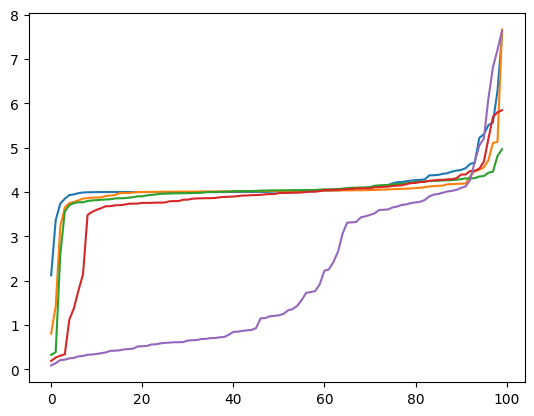

In [14]:
for idx in range(5):
    # name = 'Esomadend_Isomadend'
    name = 'Esomadend_Isomadend'
    print(np.sum(res_dict[name]['error_list'][idx] < 3))
    plt.plot(np.sort(res_dict[name]['error_list'][idx]))

KeyError: 'Esoma_Isoma'

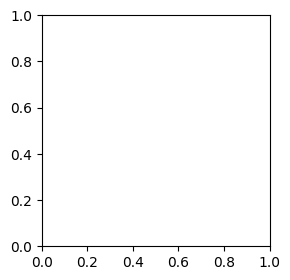

In [9]:
color_dict = {
        'Edend_Isoma': 'C0', 'Edend_Idend': 'slateblue', 'Edend_Isomadend': 'lightsteelblue',
        'Esoma_Isoma': 'C3', 'Esoma_Idend': 'darkorange', 'Esoma_Isomadend': 'rosybrown',
        'Esomadend_Isoma': 'C2', 'Esomadend_Idend': 'palegreen', 'Esomadend_Isomadend': 'darkseagreen'}

legend_dict = {
        'Edend_Idend': '$\\rm{E_{d} \\ I_{d}}$', 'Edend_Isoma': '$\\rm{E_{d} \\ I_{s}}$', 'Edend_Isomadend': '$\\rm{E_{d} \\ I_{sd}}$',
        'Esoma_Idend': '$\\rm{E_{s} \\ I_{d}}$', 'Esoma_Isoma': '$\\rm{E_{s} \\ I_{s}}$', 'Esoma_Isomadend': '$\\rm{E_{s} \\ I_{sd}}$',
        'Esomadend_Idend': '$\\rm{E_{sd} \\ I_{d}}$', 'Esomadend_Isoma': '$\\rm{E_{sd} \\ I_{s}}$', 'Esomadend_Isomadend': '$\\rm{E_{sd} \\ I_{sd}}$'}


plot_groups = [
        ['Esoma_Isoma', 'Esoma_Idend', 'Esoma_Isomadend'],
        ['Edend_Isoma', 'Edend_Idend', 'Edend_Isomadend'],
        ['Esomadend_Isoma', 'Esomadend_Idend', 'Esomadend_Isomadend']]

labelsize = 16
ticksize = 12
legendsize = 11
linewidth = 2
xticks = np.array(list(range(1,6)))

plt.figure(figsize=(10,3))
for plot_idx, group in enumerate(plot_groups):
    plt.subplot(1,3,plot_idx+1)
    for name in group:
        label = legend_dict[name]
        color = color_dict[name]
        error_avg = np.mean(np.array(res_dict[name]['error_list']), axis=1)
        error_std = np.std(np.array(res_dict[name]['error_list']), axis=1) / np.sqrt(250)

        plt.errorbar(x=xticks, y=error_avg, yerr=error_std, linewidth=linewidth, label=label, capsize=6, color=color)


    plt.xticks(fontsize=ticksize)
    plt.yticks(fontsize=ticksize)
    plt.legend(fontsize=legendsize, loc='lower left')
    plt.ylabel('Error', fontsize=labelsize)
    plt.xlabel('Flow Epoch', fontsize=labelsize)
#     plt.ylim(0, 2.1)
plt.tight_layout()
# plt.savefig('../figures/memorycontext_error_comparison.svg')

(array([183.,  25.,  11.,   3.,   3.,   5.,   7.,   0.,   1.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   1.,   3.,   1.,   0.,   2.,   2.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1.92795665,  2.65394587,  3.37993508,  4.1059243 ,  4.83191352,
         5.55790274,  6.28389196,  7.00988118,  7.7358704 ,  8.46185961,
         9.18784883,  9.91383805, 10.63982727, 11.36581649, 12.09180571,
        12.81779492, 13.54378414, 14.26977336, 14.99576258, 15.7217518 ,
        16.44774102, 17.17373024, 17.89971945, 18.62570867, 19.35169789,
        20.07768711, 20.80367633, 21.52966555, 22.25565476, 22.98164398,
        23.7076332 ]),
 <BarContainer object of 30 artists>)

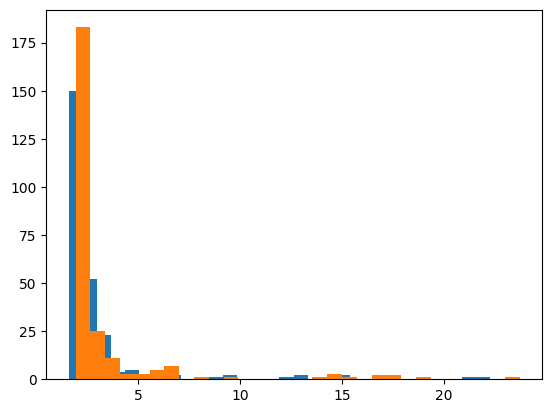

In [18]:
plt.hist(np.array(res_dict['Esoma_Isomadend']['error_list'][1]), bins=30)
plt.hist(np.array(res_dict['Edend_Idend']['error_list'][1]), bins=30)

In [20]:
np.min(np.array(res_dict['Esoma_Isomadend']['error_list'][0]))

1.896816779206812